<span style="text-align: center; color:#009999;">

# [LGBIO2050] - Medical Imaging
## *Edge detection*
</span>

### Professors :   
- Prof. G. Kerckhofs  
- Prof. J. Lee
- Prof. B. Macq
- Prof. G. Duchêne
    
### Teaching assistants : 
- Pauline Hermans (pauline.hermans@uclouvain.be)
- Nicolas Delinte (nicolas.delinte@uclouvain.be)
- Simon Francois (simon.b.francois@uclouvain.be)

**2026-2027**

<span style="color:#009999;">
 
## 1. Guidelines and Deliverables
</span>
 
- This assignment is due on **14th October 2026**.
- The jupyter notebook containing the code and **detailed answers** to the questions must be delivered in an archive (.zip folder) on Moodle, with *"Markdown cells"* containing the answers to the questions and *"Code cells"* containing the code you implemented. The answers have to be written in English.
- This work must comply with the **EPL AI Guidelines** (available on Moodle) concerning the responsible use of AI in student work. Copying code or answers from other groups or from the internet is strictly prohibited. **Any source used for inspiration must be clearly acknowledged and referenced.**
- At the end of the semester, an **individual evaluation** will allow you to demonstrate that you have a good understanding of the challenge, both in terms of the code you have written and the answers to the reflection questions. Make sure that **all group members are familiar with each challenge and understand how it works**.
- The **presentation and overall formatting of your notebook** will also be taken into account in the assessment. Make sure to **write clean, efficient, well-structured code and comment it** appropriately to make it easy to understand. Your outputs and figures should also be clear and well-presented (do not forget titles, legends, etc. where appropriate). Pay particular attention to your answers to the questions as well. **Structure your explanations clearly** and use titles, subtitles, figures, and other relevant elements to make your **answers clear and precise**.  

<span style="color:#009999;">
    
## 2. Context and objective 
</span>

 Anatomical structure segmentation on images is an important part of many medical applications. It is a process difficult to automate and it can be very time consuming if done manually. Edge detection, also called border detection, can sometimes be used in a segmentation pipeline. For this project, you will understand and implement a famous automatic edge detector called the "Canny edge detector". It is composed of the following 5 steps: 

1. Noise reduction: reduce image noise by using a simple gaussian filter to smooth the image. You can use one already implemented (the required imports are already provided). 

2. Compute image gradient intensity and direction: implement a function to compute the image gradient in both direction using Sobel operator. These images can then be combined to compute the norm and the slope direction of the gradient.

$$
|G|=\sqrt{G_{x}^{2}+G_{y}^{2}}
$$ 

$$
\theta(x,y)=arctan(\frac{G_{y}}{G_{x}})
$$

3.	Edge thinning: the next step is to reduce the borders thickness. You can use the function `thinning()` already implemented to do this step.

4.	Double thresholding: the double threshold step aims at separating borders into 2 classes, strong borders when the intensity is above the strong threshold and weak borders when the intensity is between the weak threshold and the strong threshold, the rest of the pixels can be put to a background value of 0. You can use for example as strong and weak threshold 10% and 5% of the max value of the image respectively.
 
5.	Weak borders evaluation: based on the threshold results, the last step consists of sorting the weak borders into strong borders or background. Weak borders must be transformed to strong ones if at least one of the pixels around the one being processed is a strong border. If not, a weak border joins the dark side.

The 3 following images are available to test your Canny edge detector implementation.

In [2]:
from skimage.io import imread
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, convolve

img_lung = imread('imgs/CT_Lung.jpg')
img_brain = imread('imgs/MRI_Brain.jpg')
img_pregnancy = imread('imgs/CT_Pregnancy.jpg')

<span style="color:#009999;"> 

## 3. Canny Edge Detector 
</span>

<div class="alert alert-info">

### QUESTION 1
Implement a Canny Edge Detector using the 5 steps described above. 

Show and comment briefly the result after each step of the pipeline.

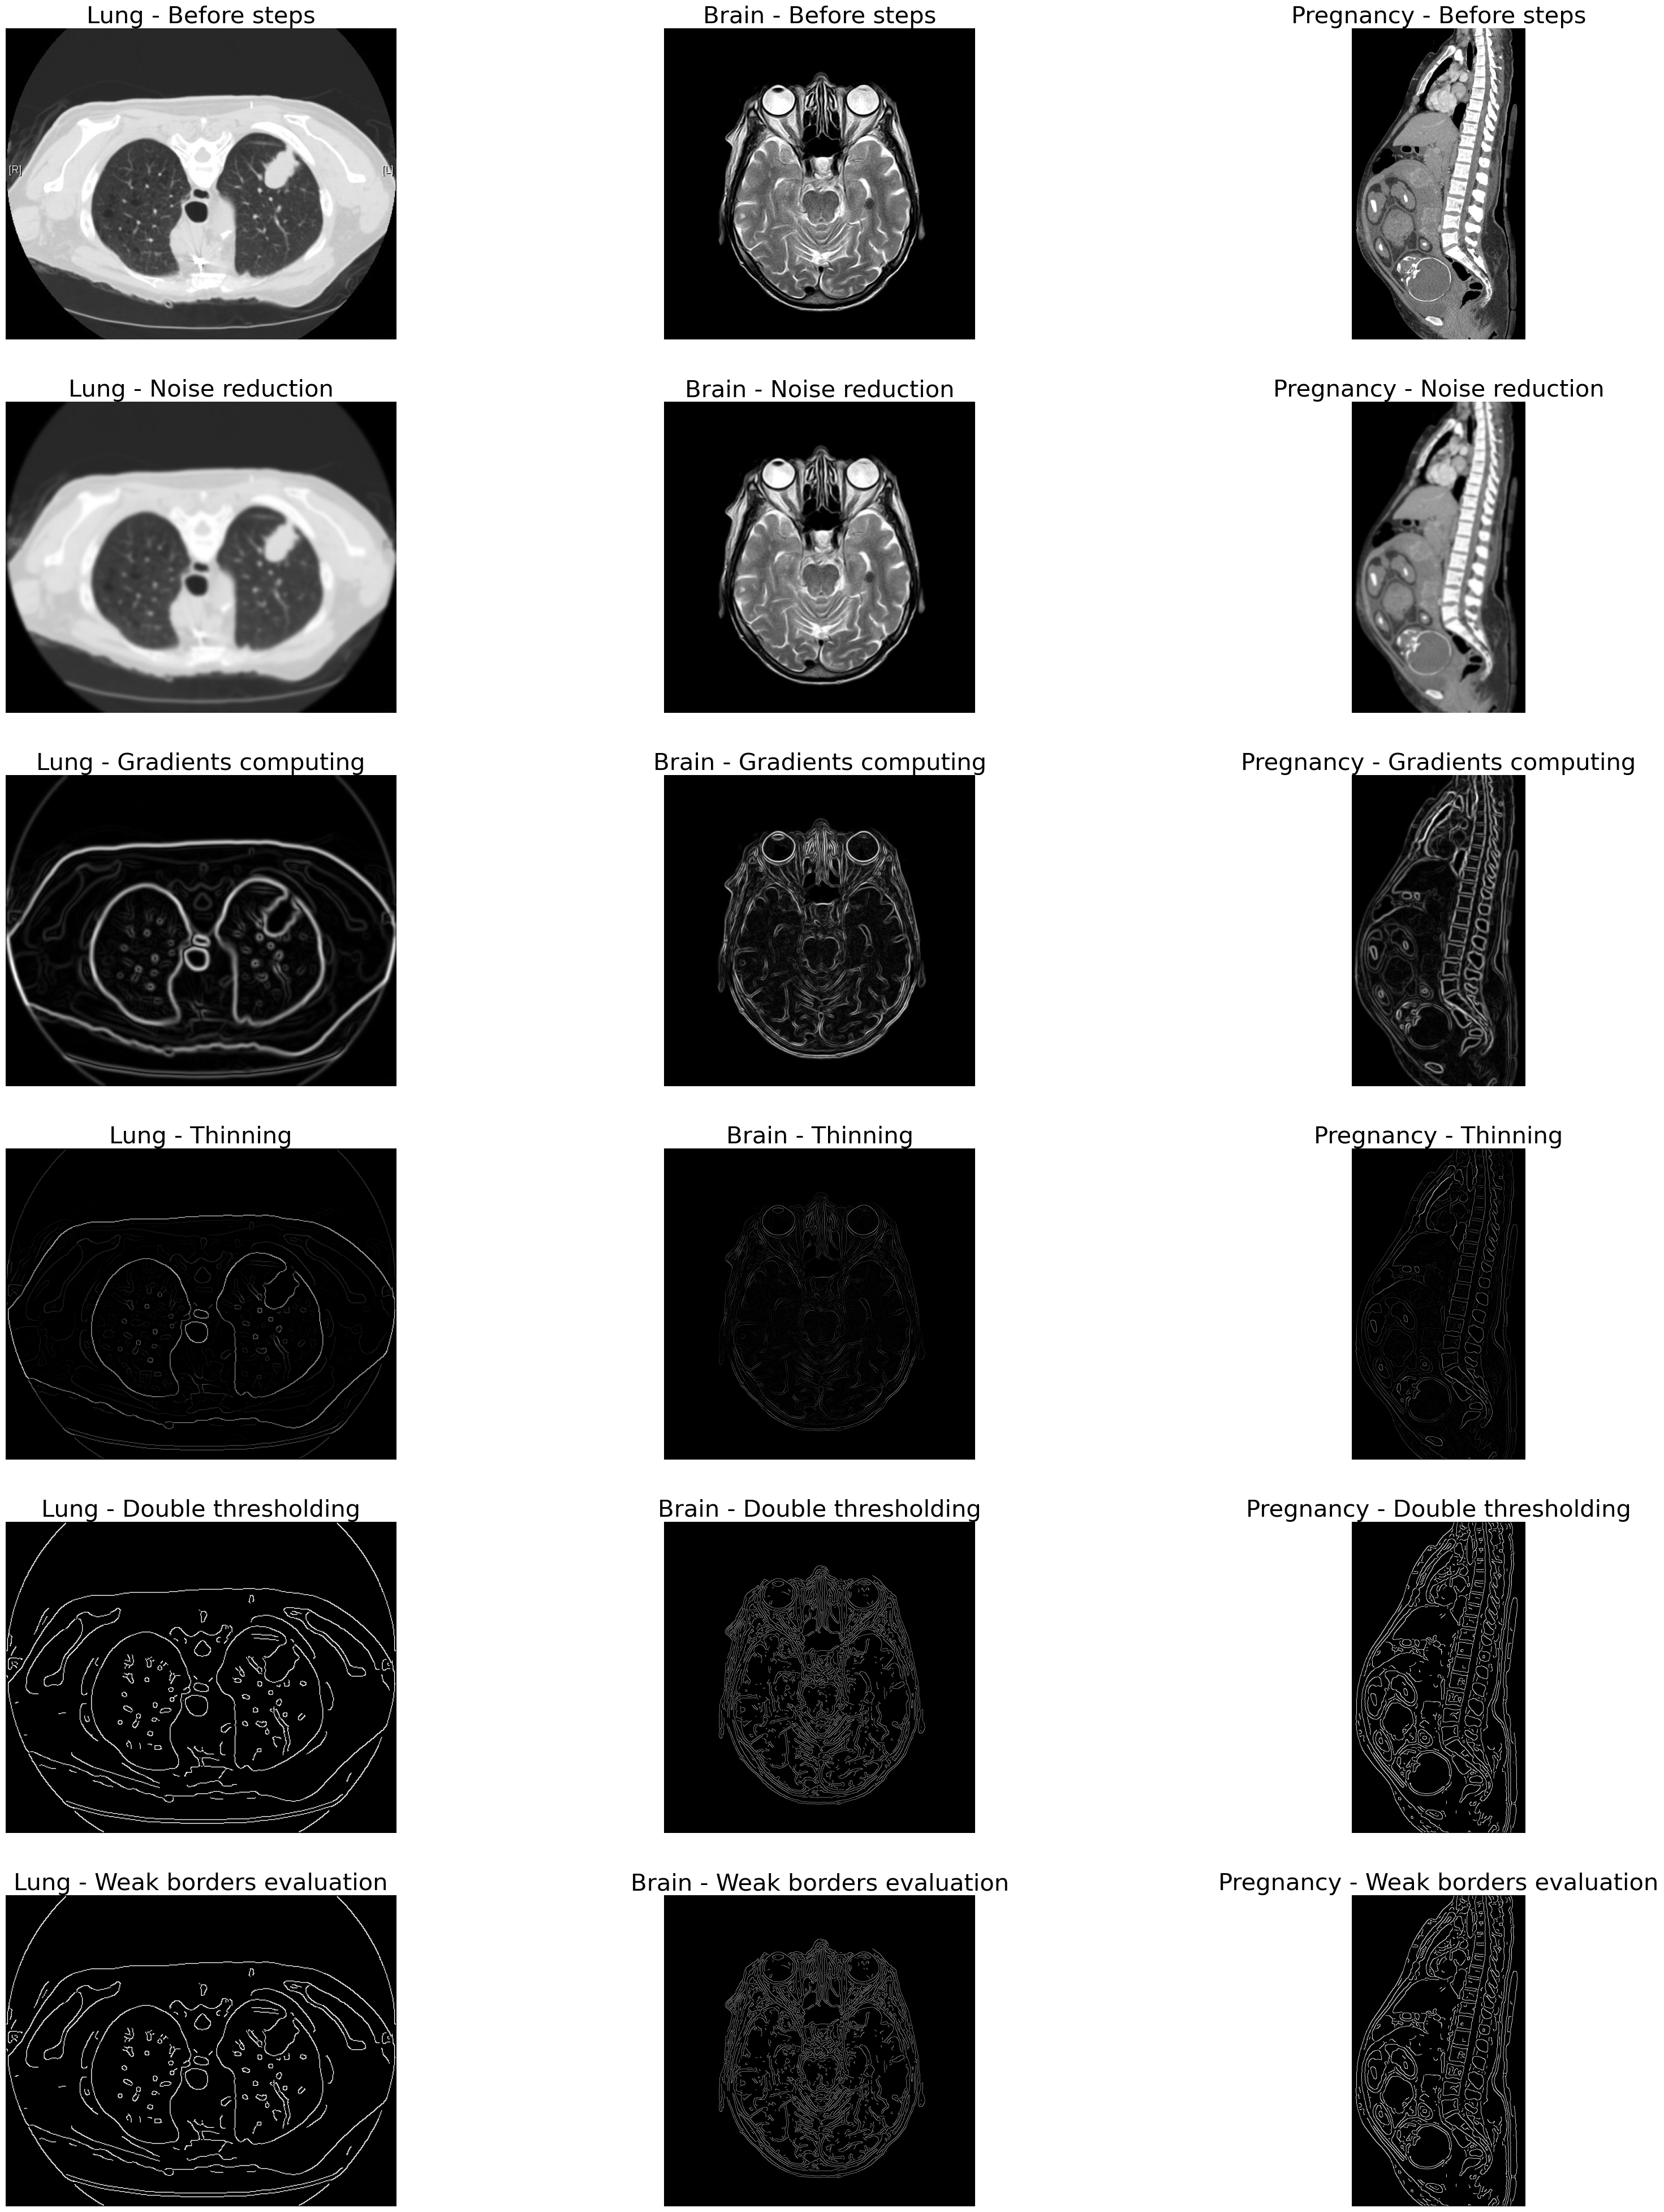

In [5]:
from skimage.color import rgb2gray

#Put the images from RGB to gray
gray_img_lung = rgb2gray(img_lung)
gray_img_pregnancy = rgb2gray(img_pregnancy)
gray_img_brain = img_brain

#Rescale the images
gray_img_lung = np.round(255*gray_img_lung).astype(np.uint8)
gray_img_pregnancy = np.round(255*gray_img_pregnancy).astype(np.uint8)

        
def noise_reduction(im, sigma):
    return gaussian_filter(im.astype(np.float32), sigma)

def gradients_computing(im):
    
    #Sabel operators
    S1 = np.array([[-1,0,1], [-2,0,2], [-1,0,1]], dtype=np.int32)
    S2 = np.array([[1,2,1], [0,0,0], [-1,-2,-1]], dtype=np.int32)
    
    #Convolution
    Gx = convolve(im,S1)
    Gy = convolve(im,S2)
    
    #Apply the formulae
    G = np.hypot(Gx,Gy)
    theta = np.arctan2(Gy,Gx)
    
    return G, theta
    
def thinning(img, angles):
    """
    Parameters
    ----------
    img : numpy.ndarray
        2D image containing the gradient magnitudes on which the edges have to be thinned.
    angles : numpy.ndarray
        2D array of the same size as img, containing the gradient angles in radians.

    Returns
    -------
    numpy.ndarray
        Thinned image.
    """
    M, N = img.shape
    Z = np.zeros((M, N), dtype=np.int32)
    angle = angles * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1, M - 1):
        for j in range(1, N - 1):

            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = img[i, j + 1]
                r = img[i, j - 1]

            elif (22.5 <= angle[i, j] < 67.5):
                q = img[i - 1, j + 1]
                r = img[i + 1, j - 1]

            elif (67.5 <= angle[i, j] < 112.5):
                q = img[i - 1, j]
                r = img[i + 1, j]

            elif (112.5 <= angle[i, j] < 157.5):
                q = img[i - 1, j - 1]
                r = img[i + 1, j + 1]

            if (img[i, j] >= q) and (img[i, j] >= r):
                Z[i, j] = img[i, j]
            else:
                Z[i, j] = 0
    return Z

def double_thresholding(im, strong_threshold_ratio, weak_threshold_ratio):
    
    #Make the thresholds 
    strong_threshold = im.max() * strong_threshold_ratio
    weak_threshold = im.max() * weak_threshold_ratio
    
    #Create a new array for the new image
    M, N = im.shape
    Z = np.zeros((M, N), dtype=np.int32)
    
    #Apply the conditions asked for our new image
    Z[im>=strong_threshold] = 255
    Z[(im<strong_threshold) & (im>=weak_threshold)] = 50
    
    return Z

def weak_borders_evaluation(im):
    
    #Check if the pixel has a strong neighbour and if yes, put it strong too
    M, N = im.shape
    for i in range(1, M - 1):
        for j in range(1, N - 1):
            if im[i,j] == 50 :
                if (im[i+1,j] == 255) or (im[i+1,j+1] == 255) or (im[i+1,j-1] == 255) or (im[i,j+1] == 255) or (im[i,j-1] == 255) or (im[i-1,j+1] == 255) or (im[i-1,j] == 255) or (im[i-1,j-1] == 255):
                    im[i,j] = 255
                else : 
                    im[i,j] = 0
            else :
                continue
    
    return im

#Call the variables
step1_lung = noise_reduction(gray_img_lung, 2)
step1_brain = noise_reduction(gray_img_brain, 2)
step1_pregnancy = noise_reduction(gray_img_pregnancy, 2)

step2_lung_G, step2_lung_theta = gradients_computing(step1_lung)
step2_brain_G, step2_brain_theta = gradients_computing(step1_brain)
step2_pregnancy_G, step2_pregnancy_theta = gradients_computing(step1_pregnancy)

step3_lung = thinning(step2_lung_G, step2_lung_theta)
step3_brain = thinning(step2_brain_G, step2_brain_theta)
step3_pregnancy = thinning(step2_pregnancy_G, step2_pregnancy_theta)

step4_lung = double_thresholding(step3_lung, 0.1, 0.05)
step4_brain = double_thresholding(step3_brain, 0.1, 0.05)
step4_pregnancy = double_thresholding(step3_pregnancy, 0.1, 0.05)

step5_lung = weak_borders_evaluation(step4_lung)
step5_brain = weak_borders_evaluation(step4_brain)
step5_pregnancy = weak_borders_evaluation(step4_pregnancy)

#Plot the results
fig, ax = plt.subplots(6,3,figsize=(40,50))

ax[0,0].imshow(gray_img_lung, cmap='gray')
ax[0,0].set_title('Lung - Before steps', fontsize=30)
ax[0,0].axis("off")
ax[0,1].imshow(gray_img_brain, cmap='gray')
ax[0,1].set_title('Brain - Before steps', fontsize=30)
ax[0,1].axis("off")
ax[0,2].imshow(gray_img_pregnancy, cmap='gray')
ax[0,2].set_title('Pregnancy - Before steps', fontsize=30)
ax[0,2].axis("off")

ax[1,0].imshow(step1_lung, cmap='gray')
ax[1,0].set_title('Lung - Noise reduction', fontsize=30)
ax[1,0].axis("off")
ax[1,1].imshow(step1_brain, cmap='gray')
ax[1,1].set_title('Brain - Noise reduction', fontsize=30)
ax[1,1].axis("off")
ax[1,2].imshow(step1_pregnancy, cmap='gray')
ax[1,2].set_title('Pregnancy - Noise reduction', fontsize=30)
ax[1,2].axis("off")

ax[2,0].imshow(step2_lung_G, cmap='gray')
ax[2,0].set_title('Lung - Gradients computing', fontsize=30)
ax[2,0].axis("off")
ax[2,1].imshow(step2_brain_G, cmap='gray')
ax[2,1].set_title('Brain - Gradients computing', fontsize=30)
ax[2,1].axis("off")
ax[2,2].imshow(step2_pregnancy_G, cmap='gray')
ax[2,2].set_title('Pregnancy - Gradients computing', fontsize=30)
ax[2,2].axis("off")

ax[3,0].imshow(step3_lung, cmap='gray')
ax[3,0].set_title('Lung - Thinning', fontsize=30)
ax[3,0].axis("off")
ax[3,1].imshow(step3_brain, cmap='gray')
ax[3,1].set_title('Brain - Thinning', fontsize=30)
ax[3,1].axis("off")
ax[3,2].imshow(step3_pregnancy, cmap='gray')
ax[3,2].set_title('Pregnancy - Thinning', fontsize=30)
ax[3,2].axis("off")

ax[4,0].imshow(step4_lung, cmap='gray')
ax[4,0].set_title('Lung - Double thresholding', fontsize=30)
ax[4,0].axis("off")
ax[4,1].imshow(step4_brain, cmap='gray')
ax[4,1].set_title('Brain - Double thresholding', fontsize=30)
ax[4,1].axis("off")
ax[4,2].imshow(step4_pregnancy, cmap='gray')
ax[4,2].set_title('Pregnancy - Double thresholding', fontsize=30)
ax[4,2].axis("off")

ax[5,0].imshow(step5_lung, cmap='gray')
ax[5,0].set_title('Lung - Weak borders evaluation', fontsize=30)
ax[5,0].axis("off")
ax[5,1].imshow(step5_brain, cmap='gray')
ax[5,1].set_title('Brain - Weak borders evaluation', fontsize=30)
ax[5,1].axis("off")
ax[5,2].imshow(step5_pregnancy, cmap='gray')
ax[5,2].set_title('Pregnancy - Weak borders evaluation', fontsize=30)
ax[5,2].axis("off")


plt.show()

<div class="alert alert-info">

### QUESTION 2
Explain how the `thinning()` function works for the step 3. 
    

For each pixel, we check if it is the one with the maximum gradients magnitude compared to its two neighbours in the gradient direction.
If it is, we keep it like it is and if not, we set it to 0.
Thanks to thinning(), we transform a blurred line in a clear one.

<div class="alert alert-info">

### QUESTION 3
How does the strong and weak thresholds in step 4 influence the final detected edges ? 

With higher thresholds, we have less detected edges (so sometimes important ones are missing). With lower thresholds, we have more detected edges (so sometimes that adds noise to the image).

<div class="alert alert-info">

### BONUS QUESTION
Show the resulting borders in color on top of the original images. 

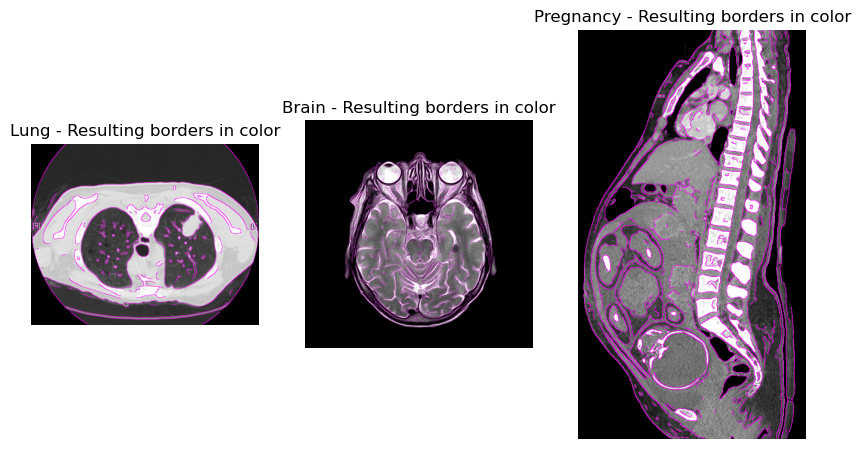

In [93]:
#Create our new images
img_lung_color = img_lung.copy()
img_brain_color = img_brain.copy()
img_pregnancy_color = img_pregnancy.copy()

#Put the gray image to RGB
rgb_img_brain_color = np.stack((img_brain_color, img_brain_color, img_brain_color), axis=-1)

#Define the color that we want (magenta)
color = [255,0,255]

#If the pixel is an edge, put it in color
img_lung_color[step5_lung==255] = color
rgb_img_brain_color[step5_brain==255] = color
img_pregnancy_color[step5_pregnancy>0] = color

#Plot the results
fig, ax = plt.subplots(1,3,figsize=(10,8))

ax[0].imshow(img_lung_color)
ax[0].set_title('Lung - Resulting borders in color')
ax[0].axis("off")
ax[1].imshow(rgb_img_brain_color)
ax[1].set_title('Brain - Resulting borders in color')
ax[1].axis("off")
ax[2].imshow(img_pregnancy_color)
ax[2].set_title('Pregnancy - Resulting borders in color')
ax[2].axis("off")

plt.show()